# GOAPified Hierarchical Agent Teams

This notebook demonstrates how **LangGOAP** replaces the LLM-based supervisors in
[LangGraph's Hierarchical Agent Teams](https://langchain-ai.github.io/langgraph/tutorials/multi_agent/hierarchical_agent_teams/)
with formal GOAP planning.

## Original vs GOAPified

| Aspect | Original LangGraph | GOAPified (LangGOAP) |
|--------|-------------------|---------------------|
| Coordination | LLM supervisor decides which agent to invoke | A\* planner selects agents based on capabilities |
| Routing | Supervisor LLM call per routing decision | No LLM needed — formal planning |
| Team selection | Supervisor must "know" all team members | Planner discovers optimal team from action specs |
| Ordering | Implicit in supervisor prompt | Explicit via preconditions/effects |

## Architecture

Each agent becomes a GOAP action. Agent capabilities are encoded as preconditions
(what the agent needs) and effects (what it produces).

### Research Team
```
search_agent:       has_topic → has_search_results       (cost=1)
web_scraper_agent:  has_search_results → has_detailed_content  (cost=2)
```

### Writing Team
```
note_taker_agent:       has_detailed_content → has_outline      (cost=1)
doc_writer_agent:       has_outline → has_document              (cost=2)
chart_generator_agent:  has_detailed_content → has_visualization (cost=1.5)
```

In [1]:
from typing import Any

from langchain_openai import ChatOpenAI

from langgoap import ActionSpec, GoalSpec, GoapGraph
from tutorial_examples.hierarchical_teams import full_team_actions

# Requires OPENAI_API_KEY environment variable
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## Define Agent Actions

Each agent from the original hierarchical teams becomes a GOAP action.

In [2]:
all_team_actions = full_team_actions(llm)

### GOAP Execution Graph

The planner discovers a plan, the executor runs each action, and the
observer checks progress — replanning automatically if something fails.

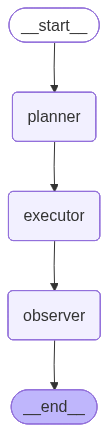

In [3]:
from IPython.display import Image, display

graph = GoapGraph(actions=all_team_actions)
display(Image(graph.compile().get_graph().draw_mermaid_png()))

## Full Research + Writing Pipeline

The planner discovers the optimal sequence across both teams:
`search → scrape → notes → write`.

In [4]:
result = GoapGraph(actions=all_team_actions).invoke(
    goal=GoalSpec(conditions={"has_document": True}),
    world_state={"has_topic": True, "topic": "AI agents"},
)

print(f"Status: {result['status']}")
print(f"Document (first 200 chars): {result['world_state']['document'][:200]}...")
print()

successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Agent sequence: {' → '.join(successful)}")

Status: goal_achieved
Document (first 200 chars): # Report on AI Agents

## 1. Definition and Characteristics of AI Agents

AI agents are sophisticated entities that utilize artificial intelligence techniques to perform tasks autonomously or semi-aut...

Agent sequence: search_agent → web_scraper_agent → note_taker_agent → doc_writer_agent


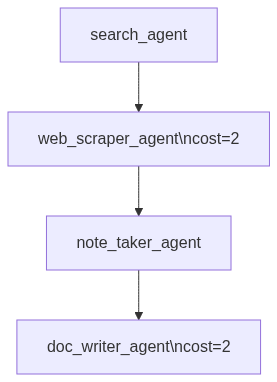

In [5]:
from langchain_core.runnables.graph_mermaid import draw_mermaid_png as _draw_png
from langgoap.viz.mermaid import render_mermaid

display(Image(_draw_png(render_mermaid(result["plan"]))))

## Research-Only Goal

When the goal only requires research output, the planner automatically
excludes the writing team — no supervisor logic needed.

In [6]:
result = GoapGraph(actions=all_team_actions).invoke(
    goal=GoalSpec(conditions={"has_detailed_content": True}),
    world_state={"has_topic": True, "topic": "LLM planning"},
)

successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Agents used: {successful}")
print(f"Writing team invoked: {'doc_writer_agent' in successful}")

Agents used: ['search_agent', 'web_scraper_agent']
Writing team invoked: False


## Visualization Goal

The chart generator requires detailed content (research team) but not
the outline or document (writing team). The planner finds the minimal path.

In [7]:
result = GoapGraph(actions=all_team_actions).invoke(
    goal=GoalSpec(conditions={"has_visualization": True}),
    world_state={"has_topic": True, "topic": "agent architectures"},
)

successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Agents used: {successful}")
print(f"Doc writer skipped: {'doc_writer_agent' not in successful}")
print(f"Visualization (first 200 chars): {result['world_state']['visualization'][:200]}...")

Agents used: ['search_agent', 'web_scraper_agent', 'chart_generator_agent']
Doc writer skipped: True
Visualization (first 200 chars): To effectively communicate the key data points regarding agent architectures, a **multi-layered bar chart** would be an ideal visualization. This chart would allow for a clear comparison of the three ...


## Multi-Goal: Document + Visualization

When both outputs are needed, the planner finds a path that satisfies
all conditions. All five agents are invoked.

In [8]:
result = GoapGraph(actions=all_team_actions).invoke(
    goal=GoalSpec(
        conditions={
            "has_document": True,
            "has_visualization": True,
        }
    ),
    world_state={"has_topic": True, "topic": "AI agents"},
)

print(f"Status: {result['status']}")
ws = result["world_state"]
print(f"Document: {ws['has_document']}")
print(f"Visualization: {ws['has_visualization']}")
successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"All agents: {successful}")

Status: goal_achieved
Document: True
Visualization: True
All agents: ['search_agent', 'web_scraper_agent', 'chart_generator_agent', 'note_taker_agent', 'doc_writer_agent']


## Cost-Based Agent Selection

When multiple agents produce the same effect, the planner picks the cheapest.

In [9]:
def quick_search(ws: dict[str, Any]) -> dict[str, Any]:
    return {"has_search_results": True, "search_results": ["quick result"]}


def deep_search(ws: dict[str, Any]) -> dict[str, Any]:
    return {"has_search_results": True, "search_results": ["deep 1", "deep 2", "deep 3"]}


cost_actions = [
    ActionSpec(
        name="quick_search",
        preconditions={"has_topic": True},
        effects={"has_search_results": True},
        cost=1.0,
        execute=quick_search,
    ),
    ActionSpec(
        name="deep_search",
        preconditions={"has_topic": True},
        effects={"has_search_results": True},
        cost=5.0,
        execute=deep_search,
    ),
]

result = GoapGraph(actions=cost_actions).invoke(
    goal=GoalSpec(conditions={"has_search_results": True}),
    world_state={"has_topic": True},
)

successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Planner chose: {successful[0]} (cost=1.0 over deep_search cost=5.0)")

Planner chose: quick_search (cost=1.0 over deep_search cost=5.0)


## Missing Capabilities

When required capabilities are missing (e.g., only writing team, no research),
the planner reports `no_plan` instead of hallucinating a path.

In [10]:
# Only writing team — no research team to produce detailed_content
# Use simple stubs since the point is demonstrating unreachable goals
def _stub_note_taker(ws: dict[str, Any]) -> dict[str, Any]:
    return {"has_outline": True, "outline": []}

def _stub_doc_writer(ws: dict[str, Any]) -> dict[str, Any]:
    return {"has_document": True, "document": ""}

writing_only = [
    ActionSpec(
        name="note_taker_agent",
        preconditions={"has_detailed_content": True},
        effects={"has_outline": True},
        execute=_stub_note_taker,
    ),
    ActionSpec(
        name="doc_writer_agent",
        preconditions={"has_outline": True},
        effects={"has_document": True},
        execute=_stub_doc_writer,
    ),
]

result = GoapGraph(actions=writing_only).invoke(
    goal=GoalSpec(conditions={"has_document": True}),
    world_state={"has_topic": True},
)

print(f"Status: {result['status']}  (no path from has_topic to has_document)")

A* found no plan for goal {'has_document': True} — Precondition(s) ['has_detailed_content'] are required by available actions but cannot be established from the current world state or by any other action. Check the action dependency chain.


Status: no_plan  (no path from has_topic to has_document)
